In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

%matplotlib inline
sns.set_style("whitegrid")

In [4]:
file_name = 'data_ab.xlsx'
users = pd.read_excel(file_name, sheet_name = 'Пользователи')
payments = pd.read_excel(file_name, sheet_name = 'Платежи')
print(f"   Пользователи: {len(users)} строк")
print(f"   Платежи: {len(payments)} строк")

   Пользователи: 1504 строк
   Платежи: 2661 строк


In [5]:
print('\nИнформация о колонках:')
display(users.info())
print('\nПервые 5 строк:')
display(users.head(5))
print('\nСтатистика по возрасту')
display(users['age'].describe())
print('\nРаспределение по группам')
display(users['group'].value_counts())
print('\nРаспределение по городам')
display(users['city'].value_counts())
print('\nРаспределение по типам устройств')
display(users['device_type'].value_counts())


Информация о колонках:
<class 'pandas.DataFrame'>
RangeIndex: 1504 entries, 0 to 1503
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      1504 non-null   int64
 1   group        1503 non-null   str  
 2   age          1504 non-null   int64
 3   city         1503 non-null   str  
 4   device_type  1504 non-null   str  
dtypes: int64(2), str(3)
memory usage: 58.9 KB


None


Первые 5 строк:


,user_id,group,age,city,device_type
0,1001,A,31,Москва,ios
1,1002,A,31,Москва,ios
2,1003,A,25,Москва,android
3,1004,A,20,Москва,ios
4,1005,A,34,Москва,ios



Статистика по возрасту


...

group
A    752
B    751
Name: count, dtype: int64


Распределение по городам


city
Москва    595
Регион    514
СПб       394
Name: count, dtype: int64


Распределение по типам устройств


device_type
android    777
ios        727
Name: count, dtype: int64

In [7]:
print('\nПустые значения в пользователях')
display(users.isna().sum())

print('\nАномалии в возрасте')
print(f"Минимальный возраст: {users['age'].min()}")
print(f"Максимальный возраст: {users['age'].max()}")


Пустые значения в пользователях


user_id        0
group          1
age            0
city           1
device_type    0
dtype: int64


Аномалии в возрасте
Минимальный возраст: -5
Максимальный возраст: 150


In [8]:
age_anomalies = users[(users['age'] < 14) | (users['age'] > 100)]
if len(age_anomalies) > 0:
    print(f"Найдено {len(age_anomalies)} аномалий")
    display(age_anomalies[['user_id' , 'age' , 'group']])

Найдено 2 аномалий


,user_id,age,group
1501,9002,-5,A
1502,9003,150,B


In [9]:
users_clean = users.copy()
users_clean = users_clean[users_clean['user_id'].notna()]
users_clean = users_clean[users_clean['group'].notna()]
users_clean = users_clean[(users_clean['age'] >= 14) | (users_clean['age'] <= 100)]
users_clean = users_clean[users_clean['city'].notna()]
users_clean = users_clean[users_clean['device_type'].notna()]
users_clean['device_type'] = users_clean['device_type'].str.lower()
users_clean['group'] = users_clean['group'].str.upper()

print(f"После очистки: {len(users_clean)} пользователей")
display(users_clean)

После очистки: 1502 пользователей


,user_id,group,age,city,device_type
0,1001,A,31,Москва,ios
1,1002,A,31,Москва,ios
2,1003,A,25,Москва,android
3,1004,A,20,Москва,ios
4,1005,A,34,Москва,ios
...,...,...,...,...,...
1497,2498,B,28,СПб,ios
1498,2499,B,42,Москва,ios
1499,2500,B,39,Москва,ios
1501,9002,A,-5,СПб,android


In [10]:
print('\nОчистка платежей')
valid_users = set(users_clean['user_id'])
payments_clean = payments[payments['user_id'].isin(valid_users)].copy()
payments_clean = payments_clean.drop_duplicates(subset = ['payment_id'])
print(f"До очистки: {len(payments)} платежей")
print(f"После очистки: {len(payments_clean)} платежей")
print(f"Удалено: {len(payments) - len(payments_clean)}")


Очистка платежей
До очистки: 2661 платежей
После очистки: 2659 платежей
Удалено: 2


In [11]:
all_users = users_clean[['user_id', 'group']].copy()
user_success = payments_clean.groupby('user_id').agg({
    'group': 'first',
    'step4_success': lambda x: x.notna().any()
}).reset_index()
user_success.columns = ['user_id', 'group', 'has_success']
display(user_success.head())

,user_id,group,has_success
0,1001.00,A,False
1,1002.00,A,False
2,1003.00,A,False
3,1004.00,A,True
4,1005.00,A,True


In [12]:
conv = user_success.groupby('group')['has_success'].agg([
    ('users', 'count'),
    ('successful', 'sum')
]).reset_index()
conv['conversion'] = conv['successful']/conv['users']
conv['conversion_pct'] = conv['conversion'] * 100
print("\nКонверсия по группам:")
display(conv)


Конверсия по группам:


,group,users,successful,conversion,conversion_pct
0,A,750,493,0.66,65.73
1,B,750,603,0.80,80.40


In [15]:
n_a = conv[conv['group'] == 'A']['users'].values[0]
n_b = conv[conv['group'] == 'B']['users'].values[0]
succ_a = conv[conv['group'] == 'A']['successful'].values[0]
succ_b = conv[conv['group'] == 'B']['successful'].values[0]
conv_a = conv[conv['group'] == 'A']['conversion'].values[0]
conv_b = conv[conv['group'] == 'B']['conversion'].values[0]
print('Итог')
print(f"Группа A: {succ_a} из {n_a} = {conv_a*100:.1f}%")
print(f"Группа B: {succ_b} из {n_b} = {conv_b*100:.1f}%")
print(f"Разница: {(conv_b - conv_a)*100:.1f}%")
print(f"Прирост: {(conv_b/conv_a - 1)*100:.1f}%")

Итог
Группа A: 493 из 750 = 65.7%
Группа B: 603 из 750 = 80.4%
Разница: 14.7%
Прирост: 22.3%


In [17]:
user_success_correct = all_users.merge(
    user_success[['user_id', 'has_success']],
    on='user_id',
    how='left'
)
user_success_correct['has_success'] = user_success_correct['has_success'].fillna(False)

conv_correct = user_success_correct.groupby('group')['has_success'].agg([
    ('users', 'count'),
    ('successful', 'sum')
]).reset_index()

conv_correct['conversion'] = conv_correct['successful'] / conv_correct['users']
conv_correct['conversion_pct'] = conv_correct['conversion'] * 100

display(conv_correct)

n_a = conv_correct[conv_correct['group'] == 'A']['users'].values[0]
n_b = conv_correct[conv_correct['group'] == 'B']['users'].values[0]
succ_a = conv_correct[conv_correct['group'] == 'A']['successful'].values[0]
succ_b = conv_correct[conv_correct['group'] == 'B']['successful'].values[0]
conv_a = conv_correct[conv_correct['group'] == 'A']['conversion'].values[0]
conv_b = conv_correct[conv_correct['group'] == 'B']['conversion'].values[0]

print(f"\nИтоговая конверсия:")
print(f"   Группа A: {succ_a} из {n_a} = {conv_a*100:.1f}%")
print(f"   Группа B: {succ_b} из {n_b} = {conv_b*100:.1f}%")
print(f"   Разница: {(conv_b - conv_a)*100:.1f}%")
print(f"   Прирост: {(conv_b/conv_a - 1)*100:.1f}%")

,group,users,successful,conversion,conversion_pct
0,A,751,493,0.66,65.65
1,B,751,603,0.80,80.29



Итоговая конверсия:
   Группа A: 493 из 751 = 65.6%
   Группа B: 603 из 751 = 80.3%
   Разница: 14.6%
   Прирост: 22.3%


In [20]:
def calculate_funnel_correct(df, group_name, all_users):
    total = all_users[all_users['group'] == group_name]['user_id'].nunique()
    
    g = df[df['group'] == group_name]
    
    step2_users = g[g['step2_entered'].notna()]['user_id'].drop_duplicates()
    step3_users = g[g['step3_confirmed'].notna()]['user_id'].drop_duplicates()
    step4_users = g[g['step4_success'].notna()]['user_id'].drop_duplicates()
    
    step2 = len(step2_users)
    step3 = len(step3_users)
    step4 = len(step4_users)
    
    return {
        'total': total,
        'step2': step2,
        'step3': step3,
        'step4': step4
    }

funnel_a = calculate_funnel_correct(payments_clean, 'A', users_clean)
funnel_b = calculate_funnel_correct(payments_clean, 'B', users_clean)

print('Воронка A:', funnel_a)
print('Воронка B:', funnel_b)

funnel_df = pd.DataFrame({
    'Этап': ['Открыл форму', 'Ввел реквизиты', 'Подтвердил', 'Успешно оплатил'],
    'Группа A': [funnel_a['total'], funnel_a['step2'], funnel_a['step3'], funnel_a['step4']],
    'Группа B': [funnel_b['total'], funnel_b['step2'], funnel_b['step3'], funnel_b['step4']]
})

funnel_df['A конверсия'] = [
    '-',
    f"{funnel_a['step2']/funnel_a['total']*100:.1f}%",
    f"{funnel_a['step3']/funnel_a['step2']*100:.1f}%",
    f"{funnel_a['step4']/funnel_a['step3']*100:.1f}%"
]

funnel_df['B конверсия'] = [
    '-',
    f"{funnel_b['step2']/funnel_b['total']*100:.1f}%",
    f"{funnel_b['step3']/funnel_b['step2']*100:.1f}%",
    f"{funnel_b['step4']/funnel_b['step3']*100:.1f}%"
]

display(funnel_df)

Воронка A: {'total': 751, 'step2': 670, 'step3': 547, 'step4': 492}
Воронка B: {'total': 751, 'step2': 708, 'step3': 645, 'step4': 604}


,Этап,Группа A,Группа B,A конверсия,B конверсия
0,Открыл форму,751,751,-,-
1,Ввел реквизиты,670,708,89.2%,94.3%
2,Подтвердил,547,645,81.6%,91.1%
3,Успешно оплатил,492,604,89.9%,93.6%


In [21]:
p_a = succ_a / n_a
p_b = succ_b / n_b
p_pooled = (succ_a + succ_b) / (n_a + n_b)

se = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_a + 1/n_b))
z_stat = (p_b - p_a) / se
p_value = 1 - norm.cdf(z_stat)

print(f"Z-статистика: {z_stat:.4f}")
print(f"P-значение (одностороннее): {p_value:.6f}")

if p_value < 0.05:
    print("\nРезультат статистически значим (p < 0.05)")
    print("Новая форма лучше")
else:
    print("\nРезультат не значим (p >= 0.05)")
    print("Нет оснований утверждать, что форма лучше")

Z-статистика: 6.3909
P-значение (одностороннее): 0.000000

Результат статистически значим (p < 0.05)
Новая форма лучше


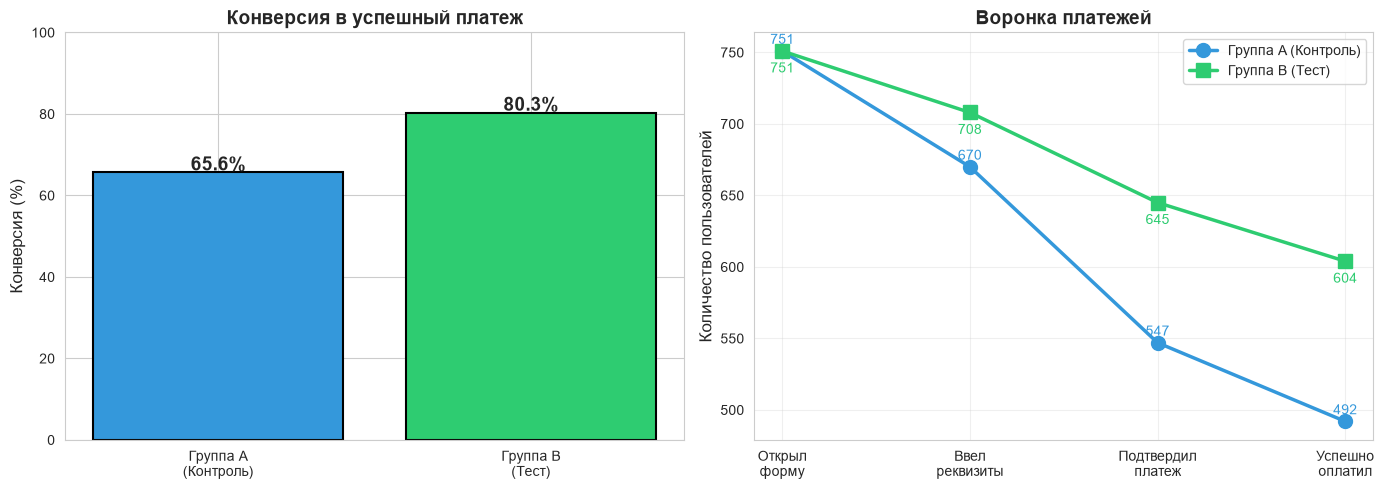

График сохранен в 'conversion_funnel.png'


In [22]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(['Группа A\n(Контроль)', 'Группа B\n(Тест)'], 
        [conv_a*100, conv_b*100],
        color=['#3498db', '#2ecc71'],
        edgecolor='black',
        linewidth=1.5)

for i, v in enumerate([conv_a*100, conv_b*100]):
    ax1.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=14, fontweight='bold')

ax1.set_ylabel('Конверсия (%)', fontsize=12)
ax1.set_title('Конверсия в успешный платеж', fontsize=14, fontweight='bold')
ax1.set_ylim(0, 100)

steps = ['Открыл\nформу', 'Ввел\nреквизиты', 'Подтвердил\nплатеж', 'Успешно\nоплатил']
values_a = [funnel_a['total'], funnel_a['step2'], funnel_a['step3'], funnel_a['step4']]
values_b = [funnel_b['total'], funnel_b['step2'], funnel_b['step3'], funnel_b['step4']]

ax2.plot(steps, values_a, marker='o', linewidth=2.5, markersize=10, 
         label='Группа A (Контроль)', color='#3498db')
ax2.plot(steps, values_b, marker='s', linewidth=2.5, markersize=10, 
         label='Группа B (Тест)', color='#2ecc71')

for i, v in enumerate(values_a):
    ax2.text(i, v + 5, str(v), ha='center', fontsize=10, color='#3498db')
for i, v in enumerate(values_b):
    ax2.text(i, v - 15, str(v), ha='center', fontsize=10, color='#2ecc71')

ax2.set_ylabel('Количество пользователей', fontsize=12)
ax2.set_title('Воронка платежей', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('conversion_funnel.png', dpi=300, bbox_inches='tight')
plt.show()

print("График сохранен в 'conversion_funnel.png'")

In [23]:
payments_with_users = payments_clean.merge(
    users_clean[['user_id', 'city', 'device_type']], 
    on='user_id', 
    how='left'
)

def calculate_segment_conversion(df, group_col):
    result = df.groupby(['group', group_col]).apply(
        lambda x: pd.Series({
            'users': x['user_id'].nunique(),
            'successful': x[x['step4_success'].notna()]['user_id'].nunique()
        })
    ).reset_index()
    result['conversion'] = result['successful'] / result['users'] * 100
    return result

print("\n По городам:")
city_conv = calculate_segment_conversion(payments_with_users, 'city')
city_pivot = city_conv.pivot(index='city', columns='group', values='conversion')
city_pivot['Разница'] = city_pivot['B'] - city_pivot['A']
display(city_pivot)

print("\nПо типу устройства:")
device_conv = calculate_segment_conversion(payments_with_users, 'device_type')
device_pivot = device_conv.pivot(index='device_type', columns='group', values='conversion')
device_pivot['Разница'] = device_pivot['B'] - device_pivot['A']
display(device_pivot)


 По городам:


group,A,B,Разница
city,,,
Москва,62.50,81.11,18.61
Регион,66.79,76.33,9.54
СПб,68.56,84.42,15.87



По типу устройства:


group,A,B,Разница
device_type,,,
android,64.29,80.00,15.71
ios,67.15,80.84,13.69


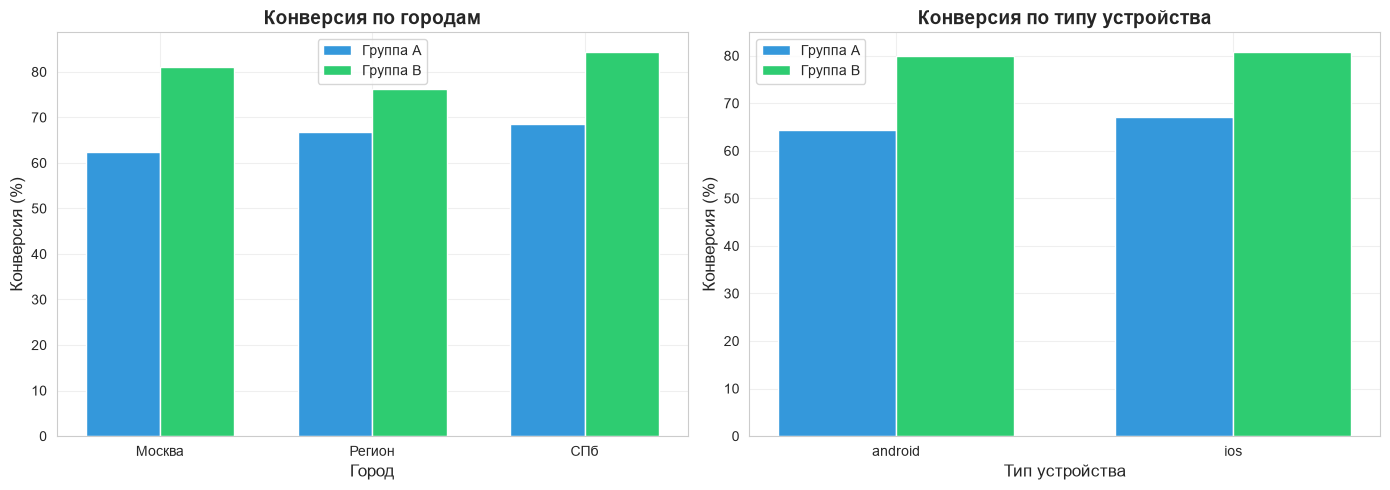

Графики сохранены в 'segment_analysis.png'


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cities = city_pivot.index.tolist()
x = np.arange(len(cities))
width = 0.35

axes[0].bar(x - width/2, city_pivot['A'], width, label='Группа A', color='#3498db')
axes[0].bar(x + width/2, city_pivot['B'], width, label='Группа B', color='#2ecc71')
axes[0].set_xlabel('Город', fontsize=12)
axes[0].set_ylabel('Конверсия (%)', fontsize=12)
axes[0].set_title('Конверсия по городам', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(cities)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

devices = device_pivot.index.tolist()
x = np.arange(len(devices))

axes[1].bar(x - width/2, device_pivot['A'], width, label='Группа A', color='#3498db')
axes[1].bar(x + width/2, device_pivot['B'], width, label='Группа B', color='#2ecc71')
axes[1].set_xlabel('Тип устройства', fontsize=12)
axes[1].set_ylabel('Конверсия (%)', fontsize=12)
axes[1].set_title('Конверсия по типу устройства', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(devices)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('segment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("Графики сохранены в 'segment_analysis.png'")